# Student Academic Success & Dropout Prediction
### AI / Machine Learning Academic Internship Project
**Project Owner:** Aryan  
**Role:** Lead Data Scientist & Project Engineer  
**Institution:** Higher Education Analytics Research & Development  
**Dataset Reference:** UCI Machine Learning Repository (Dataset ID: 697)  
**DOI:** [10.24432/C5MC89](https://doi.org/10.24432/C5MC89) | **License:** Creative Commons Attribution 4.0 International (CC BY 4.0)

## 2. Executive Summary
Student attrition in higher education represents a substantial institutional, societal, and economic challenge. Every student who departs without completing their qualification carries lost tuition revenue for the institution, personal debt without credential attainment, and depressed lifetime earning potential. 

This project develops an end-to-end, statistically validated, reproducible machine learning system designed to predict one of three student outcomes:
1. **Dropout:** Student discontinued studies prior to completion.
2. **Enrolled:** Student remains actively enrolled within nominal degree duration.
3. **Graduate:** Student successfully fulfilled curriculum requirements and graduated.

Using the official UCI Machine Learning Repository dataset (4,424 records, 36 predictors), this study rigorously evaluates two complementary operational perspectives:
- **Perspective A (Pre-Enrollment / Early-Stage Screening):** 24 audited features available at or before matriculation (demographics, parental education and occupation, admission scores, high school grades, application route, initial fee status, and macroeconomic indicators). Evaluates how early at-risk profiles can be identified for proactive advisory interventions.
- **Perspective B (Longitudinal / Academic-Progress Model):** Full 36 features incorporating first- and second-semester curricular progress (credits earned, evaluation counts, approved units, and academic GPAs). Demonstrates how progression metrics refine risk assessment.

Our experiments reveal that **Perspective A** achieves an intake baseline accuracy of **59.10%** and Macro-F1 of **0.5506**, whereas **Perspective B** leverages first-year academic milestones to reach **74.92% accuracy** and **0.7069 Macro-F1** (Random Forest Classifier). This empirical contrast proves that while pre-entry factors provide vital early alerts, first-year academic friction (particularly second-semester course failures and fee arrears) is the primary determinant of eventual retention.

## 3. Problem Statement
Traditional university retention interventions are frequently reactive: academic advisors intervene only after an academic dismissal notice is generated or after a student stops attending classes. 

To transition toward **proactive early intervention**, institutional leadership requires predictive intelligence that answers two fundamental operational questions:
1. *At the moment of enrollment*, what characteristics are associated with elevated dropout risk, and can intake counseling be triggered before classes begin?
2. *At the close of the first academic year*, how do accumulated grades and unit approvals separate transiently struggling students (`Enrolled`) from those heading toward definitive withdrawal (`Dropout`) versus timely degree completion (`Graduate`)?

This project addresses these challenges through a multiclass machine learning paradigm that accounts for class imbalance, isolates preprocessing transformations to prevent data leakage, and provides interpretable feature rankings.

## 4. Project Objectives
1. **Empirical Dataset Audit:** Download, clean, and profile the official UCI 697 dataset (4,424 rows x 37 columns) without synthetic fabrication.
2. **Data Leakage Mitigation:** Systematically verify feature availability against official definitions and implement distinct Pre-Enrollment (Perspective A) and Longitudinal (Perspective B) pipelines.
3. **Exploratory Data Analysis (EDA):** Quantify how demographic, socioeconomic, admission, academic, and financial variables correlate with student outcomes.
4. **End-to-End ML Pipelines:** Build reproducible scikit-learn pipelines with `ColumnTransformer` (StandardScaler for continuous variables, OneHotEncoder for non-ordinal categoricals).
5. **Multi-Model Benchmarking:** Train and validate Stratified Baseline, Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting, and Support Vector Classifier models using 5-Fold Stratified Cross-Validation.
6. **Class-Imbalanced Evaluation:** Prioritize Macro-F1, per-class Recall, and Confusion Matrices over raw overall accuracy.
7. **Model Explainability & Diagnostic Analysis:** Quantify global feature importance via tree-based impurity and permutation importance to extract actionable institutional insights.

## 5. Dataset Source and Description
- **Repository:** UCI Machine Learning Repository
- **Dataset Title:** *Predict Students' Dropout and Academic Success* (ID: 697)
- **Primary Source Publication:** Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2021). *Predict Students' Dropout and Academic Success*. Data, 6(11), 124. [DOI: 10.3390/data6110124](https://doi.org/10.3390/data6110124).
- **Institution:** Instituto Politécnico de Portalegre, Portugal.
- **Population:** 4,424 undergraduate students enrolled across 17 degree programs between academic years 2008/2009 and 2018/2019.
- **Attributes:** 36 input features and 1 multiclass target (`Target`).
- **Data Integrity:** Officially documented as containing zero missing values across all published cells.

## 6. Data Dictionary & Taxonomic Overview
The 36 predictors are structured across 7 functional categories:

| Category | Count | Feature Names | Description |
| :--- | :---: | :--- | :--- |
| **Demographics** | 6 | `Marital status`, `Nacionality`, `Displaced`, `Gender`, `Age at enrollment`, `International` | Student individual characteristics and residency origin |
| **Socioeconomics** | 4 | `Mother's qualification`, `Father's qualification`, `Mother's occupation`, `Father's occupation` | Parental educational attainment and ISCO occupational categories |
| **Admission & Prior Study** | 7 | `Application mode`, `Application order`, `Course`, `Daytime/evening attendance`, `Previous qualification`, `Previous qualification (grade)`, `Admission grade`, `Educational special needs` | Entrance pathways, degree choices, high school grades, and disability accommodations |
| **Financial / Institutional** | 3 | `Debtor`, `Tuition fees up to date`, `Scholarship holder` | Student debt arrears, tuition currency, and public scholarship support |
| **1st Semester Academic** | 6 | `Curricular units 1st sem (credited)`, `(enrolled)`, `(evaluations)`, `(approved)`, `(grade)`, `(without evaluations)` | Curricular volume, exam attempts, passed units, and average grade |
| **2nd Semester Academic** | 6 | `Curricular units 2nd sem (credited)`, `(enrolled)`, `(evaluations)`, `(approved)`, `(grade)`, `(without evaluations)` | Spring term curricular volume, exam attempts, passed units, and average grade |
| **Macroeconomic** | 3 | `Unemployment rate`, `Inflation rate`, `GDP` | National economic climate in Portugal during student entry cohort year |
| **Target Variable** | 1 | `Target` | 3 classes: `Dropout` (1,421; 32.1%), `Enrolled` (794; 18.0%), `Graduate` (2,209; 49.9%) |

## 7. Import Required Libraries
We import standard scientific Python libraries, setting random seeds for reproducibility.

In [1]:
import os
import sys
import io
import json
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Silence benign deprecation warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("Libraries imported successfully. Python version:", sys.version.split()[0])

Libraries imported successfully. Python version: 3.11.9


## 8. Load Dataset
We load the dataset directly from the local cache `data/data.csv` (downloaded programmatically from the official UCI repository).

In [2]:
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, 'data.csv')

if not os.path.exists(data_path):
    print("Downloading official dataset from UCI repository...")
    url = 'https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as resp:
        zip_bytes = resp.read()
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        with z.open('data.csv') as src, open(data_path, 'wb') as dst:
            dst.write(src.read())
    print("Downloaded and saved to:", data_path)
else:
    print("Loading existing local dataset from:", data_path)

df = pd.read_csv(data_path, sep=';')
# Strip trailing whitespace and tab characters from column headers
df.columns = df.columns.str.strip()
print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Loading existing local dataset from: data\data.csv
Dataset successfully loaded: 4424 rows, 37 columns.


## 9. Initial Dataset Inspection
Let's inspect the first 5 records, column data types, and overall structure.

In [3]:
print("Dataset Head (first 5 records):")
display(df.head(5))

print("\nDataset Info:")
df.info()

print("\nNumerical Summary Statistics (selected features):")
display(df[['Admission grade', 'Age at enrollment', 'Curricular units 1st sem (approved)', 
            'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (approved)', 
            'Curricular units 2nd sem (grade)', 'Unemployment rate', 'GDP']].describe().T)

Dataset Head (first 5 records):


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification               

,count,mean,std,min,25%,50%,75%,max
Admission grade,4424.0,126.978119,14.482001,95.00,117.90,126.100000,134.800000,190.000000
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.00,20.000000,25.000000,70.000000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.00,3.00,5.000000,6.000000,26.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.00,11.00,12.285714,13.400000,18.875000
Curricular units 2nd sem (approved),4424.0,4.435805,3.014764,0.00,2.00,5.000000,6.000000,20.000000
Curricular units 2nd sem (grade),4424.0,10.230206,5.210808,0.00,10.75,12.200000,13.333333,18.571429
Unemployment rate,4424.0,11.566139,2.663850,7.60,9.40,11.100000,13.900000,16.200000
GDP,4424.0,0.001969,2.269935,-4.06,-1.70,0.320000,1.790000,3.510000


## 10. Data Quality Analysis
We perform automated consistency checks across all fields.

In [4]:
print("Data Quality Checks:")
print("1. Column header whitespace stripped: OK")
print(f"2. Total columns present: {len(df.columns)}")
print("3. Target column present:", 'Target' in df.columns)
print("4. Unique data types present:", df.dtypes.unique())

Data Quality Checks:
1. Column header whitespace stripped: OK
2. Total columns present: 37
3. Target column present: True
4. Unique data types present: [dtype('int64') dtype('float64')
 <StringDtype(storage='python', na_value=nan)>]


## 11. Missing Values Analysis
We verify whether null, NaN, or empty values exist in the dataset.

In [5]:
null_counts = df.isnull().sum()
total_nulls = null_counts.sum()
print(f"Total Missing / Null Values: {total_nulls}")
assert total_nulls == 0, "Warning: Null values detected!"
print("Verification confirmed: Zero missing values found across all 4,424 observations.")

Total Missing / Null Values: 0
Verification confirmed: Zero missing values found across all 4,424 observations.


## 12. Duplicate Records Analysis
We check for exact duplicate rows.

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")
assert duplicate_count == 0, "Warning: Duplicate rows detected!"
print("Verification confirmed: Zero duplicate records across the dataset.")

Total Duplicate Rows: 0
Verification confirmed: Zero duplicate records across the dataset.


## 13. Target / Class Distribution Analysis
We evaluate the class balance between `Graduate`, `Dropout`, and `Enrolled`.

,Count,Percentage (%)
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


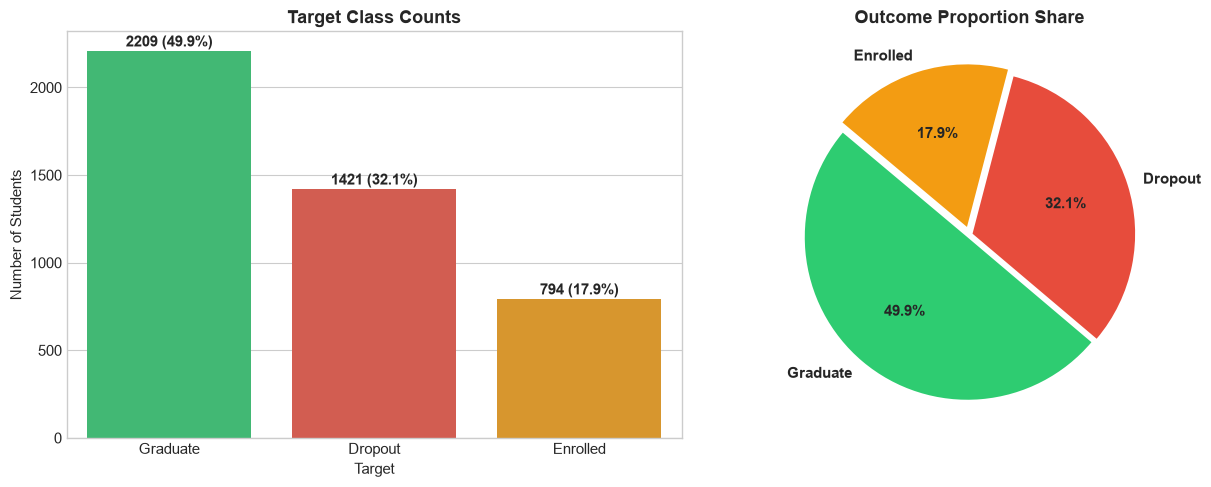

In [7]:
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
display(dist_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
palette = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f39c12'}

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax1, palette=palette, hue=target_counts.index, legend=False)
ax1.set_title('Target Class Counts', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Students')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 25, f"{v} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=[palette[k] for k in target_counts.index], explode=(0.02, 0.02, 0.05),
        startangle=140, textprops={'fontweight': 'bold', 'fontsize': 11})
ax2.set_title('Outcome Proportion Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Exploratory Data Analysis (EDA) Overview
Our exploratory analysis investigates four central research themes:
1. **Academic progression dynamics:** How unit approval counts and grades differentiate outcomes.
2. **Financial distress indicators:** The relationship between tuition fee compliance, debtor flags, and attrition.
3. **Demographic and age gradients:** Older non-traditional students versus direct secondary school entrants.
4. **Admission baseline signals:** High-school credentials and admission examination performance.

## 15. Univariate Analysis: Key Variable Distributions
We inspect the distributions of continuous features including admission scores, age at enrollment, and macroeconomic indicators.

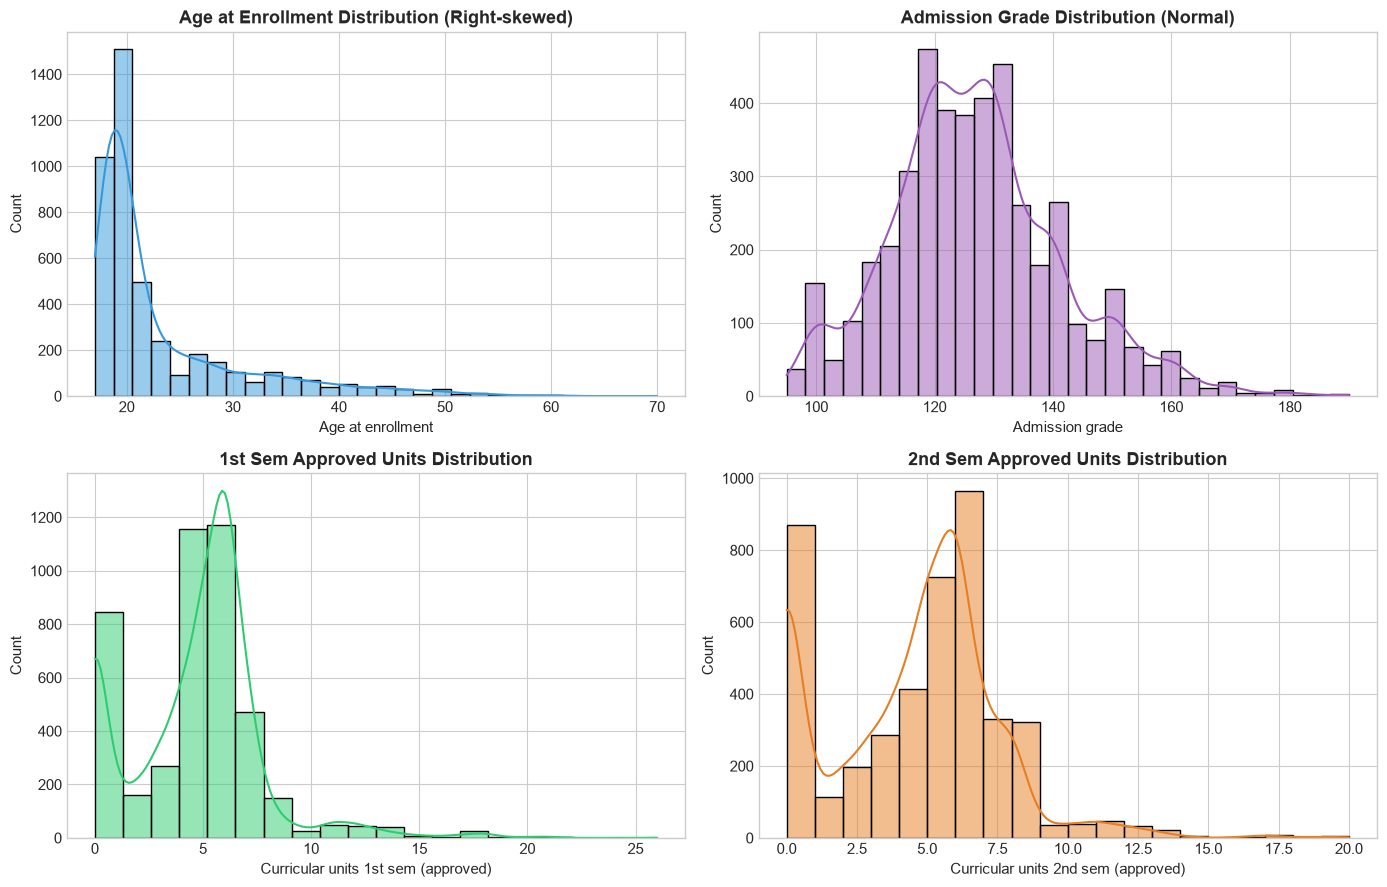

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['Age at enrollment'], kde=True, ax=axes[0, 0], color='#3498db', bins=30)
axes[0, 0].set_title('Age at Enrollment Distribution (Right-skewed)', fontweight='bold')

sns.histplot(df['Admission grade'], kde=True, ax=axes[0, 1], color='#9b59b6', bins=30)
axes[0, 1].set_title('Admission Grade Distribution (Normal)', fontweight='bold')

sns.histplot(df['Curricular units 1st sem (approved)'], kde=True, ax=axes[1, 0], color='#2ecc71', bins=20)
axes[1, 0].set_title('1st Sem Approved Units Distribution', fontweight='bold')

sns.histplot(df['Curricular units 2nd sem (approved)'], kde=True, ax=axes[1, 1], color='#e67e22', bins=20)
axes[1, 1].set_title('2nd Sem Approved Units Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 16. Bivariate Analysis: Correlates of Student Outcomes
We analyze how student status varies across financial standing, academic performance, and gender.

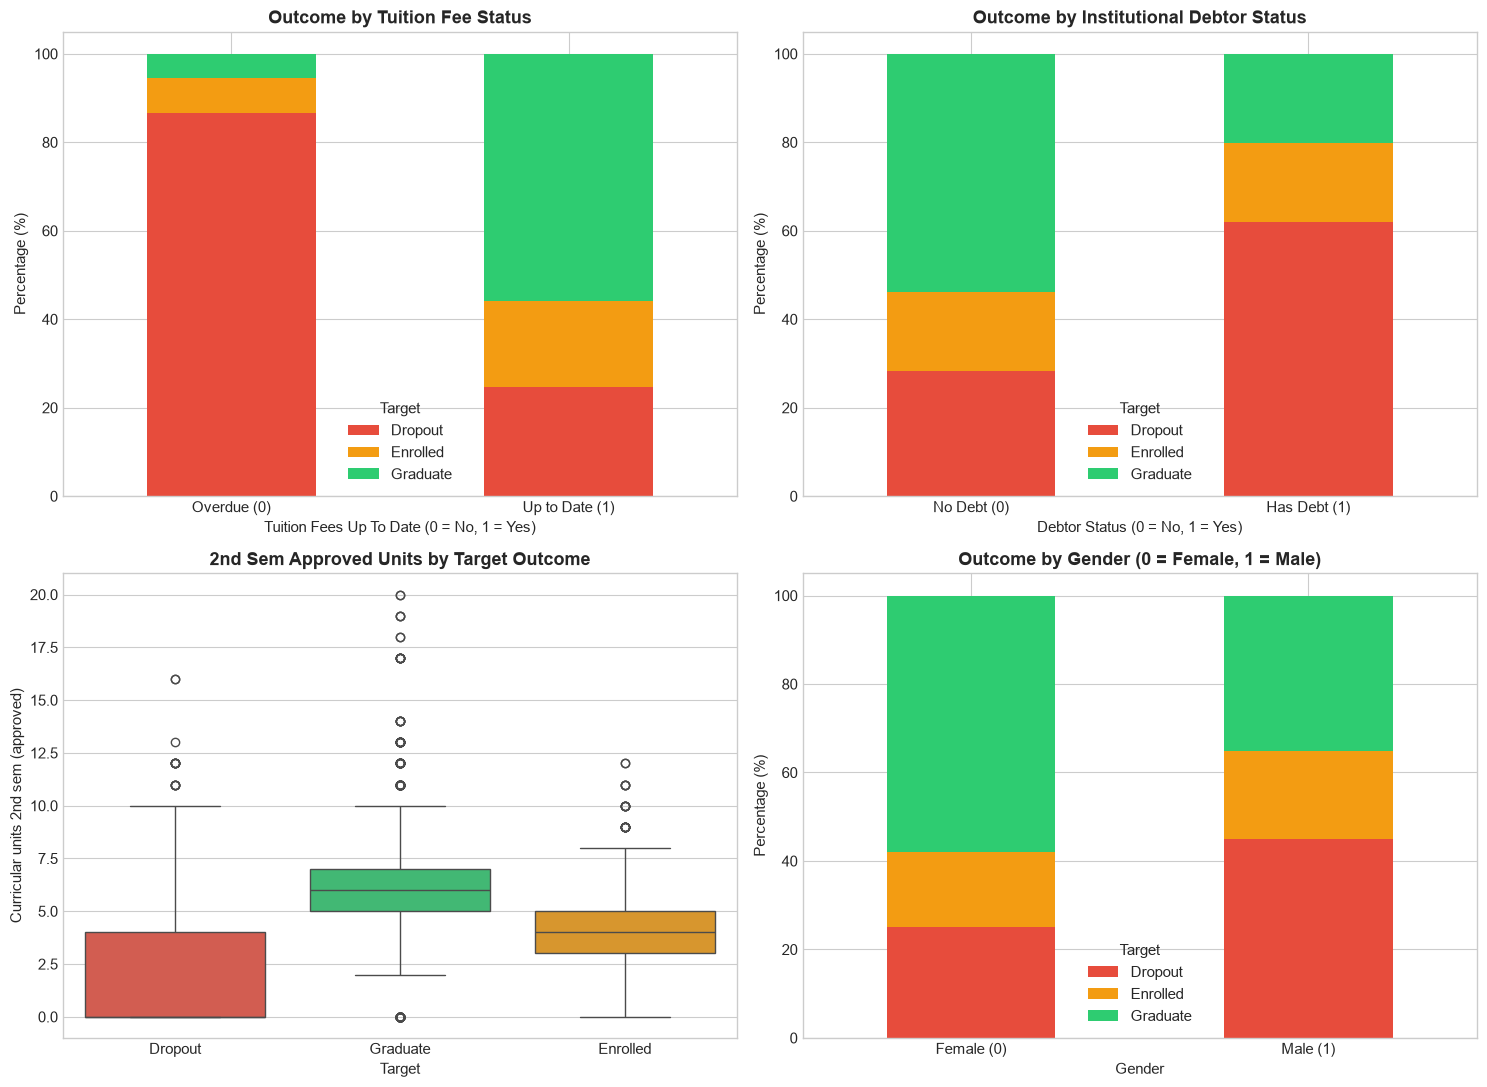

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Tuition fees up to date vs Outcome
fee_ct = pd.crosstab(df['Tuition fees up to date'], df['Target'], normalize='index') * 100
fee_ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[0, 0])
axes[0, 0].set_title('Outcome by Tuition Fee Status', fontweight='bold')
axes[0, 0].set_xlabel('Tuition Fees Up To Date (0 = No, 1 = Yes)')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].set_xticklabels(['Overdue (0)', 'Up to Date (1)'], rotation=0)

# 2. Debtor status vs Outcome
debt_ct = pd.crosstab(df['Debtor'], df['Target'], normalize='index') * 100
debt_ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[0, 1])
axes[0, 1].set_title('Outcome by Institutional Debtor Status', fontweight='bold')
axes[0, 1].set_xlabel('Debtor Status (0 = No, 1 = Yes)')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_xticklabels(['No Debt (0)', 'Has Debt (1)'], rotation=0)

# 3. 2nd sem approved units boxplot
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (approved)', palette=palette, ax=axes[1, 0], hue='Target', legend=False)
axes[1, 0].set_title('2nd Sem Approved Units by Target Outcome', fontweight='bold')

# 4. Gender breakdown
gender_ct = pd.crosstab(df['Gender'], df['Target'], normalize='index') * 100
gender_ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[1, 1])
axes[1, 1].set_title('Outcome by Gender (0 = Female, 1 = Male)', fontweight='bold')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_xticklabels(['Female (0)', 'Male (1)'], rotation=0)

plt.tight_layout()
plt.show()

## 17. Multivariate Analysis
We evaluate interactions between age at enrollment, admission grades, and final outcome.

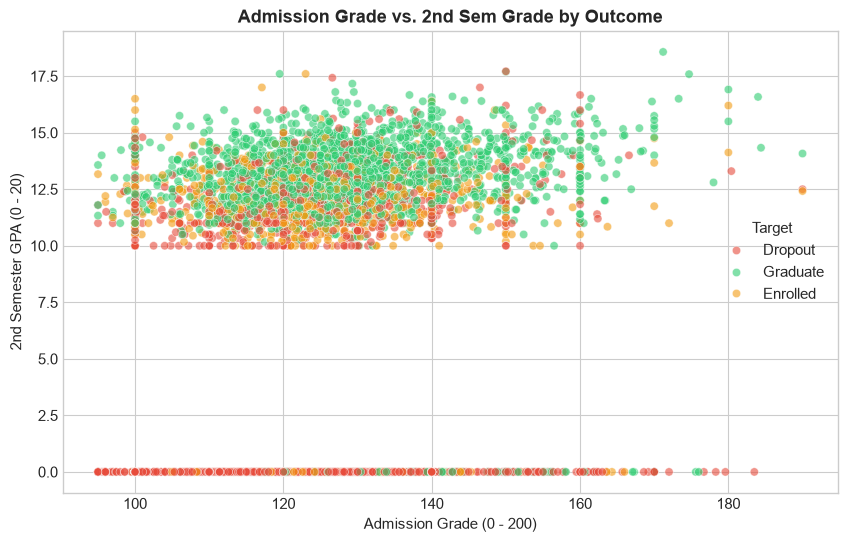

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Admission grade', y='Curricular units 2nd sem (grade)',
    hue='Target', palette=palette, alpha=0.6, ax=ax
)
ax.set_title('Admission Grade vs. 2nd Sem Grade by Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Admission Grade (0 - 200)')
ax.set_ylabel('2nd Semester GPA (0 - 20)')
plt.show()

## 18. Correlation Analysis
We compute Pearson correlation coefficients across numerical indicators.

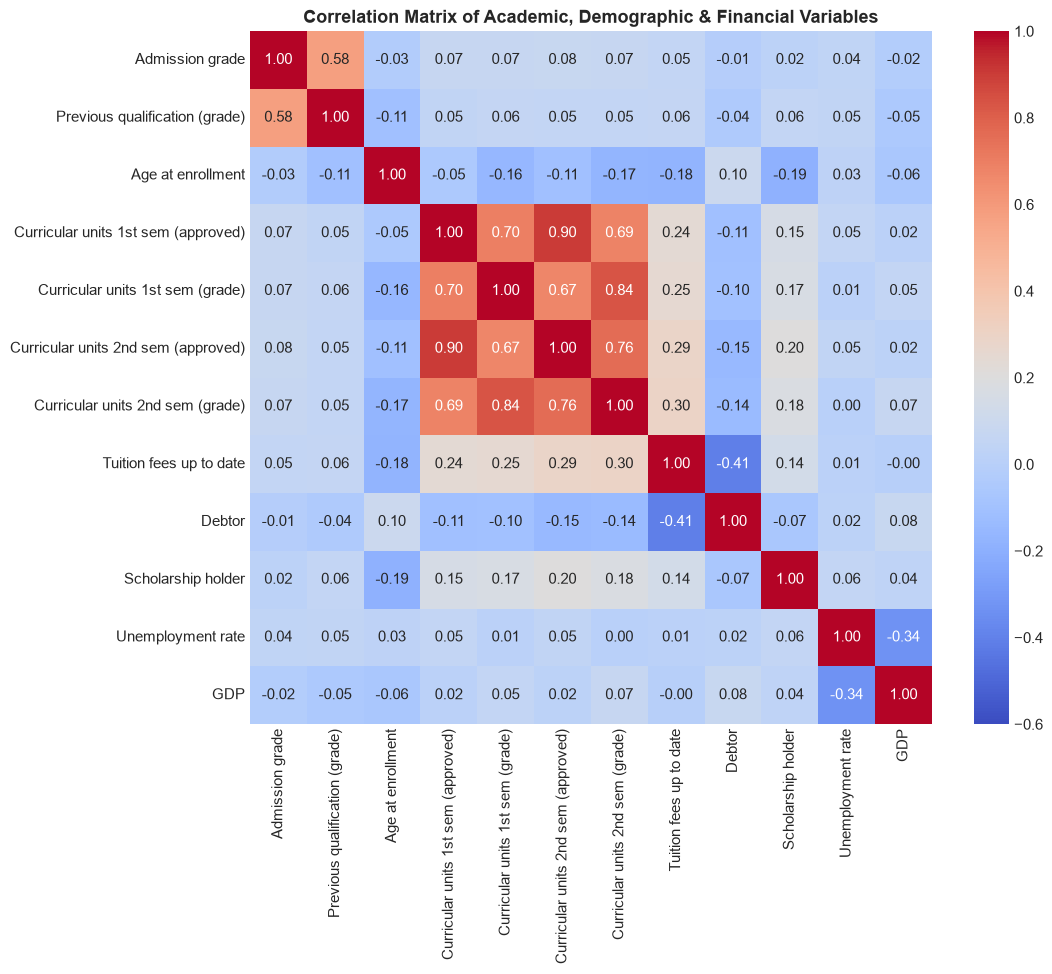

In [11]:
corr_features = [
    'Admission grade', 'Previous qualification (grade)', 'Age at enrollment',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Tuition fees up to date', 'Debtor', 'Scholarship holder',
    'Unemployment rate', 'GDP'
]

corr = df[corr_features].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-0.6, vmax=1.0)
ax.set_title('Correlation Matrix of Academic, Demographic & Financial Variables', fontweight='bold')
plt.show()

## 19. Feature Verification & Perspective Separation
To address **temporal data leakage**, we distinguish two operational perspectives:
- **Perspective A (Pre-Enrollment / Early Stage):** Exactly 24 verified features available at the admissions threshold.
- **Perspective B (Academic-Progress / Longitudinal):** Full 36 features including 1st and 2nd semester curricular outcomes.

In [12]:
# Target mapping
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
inv_target_map = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
target_names = ['Dropout', 'Enrolled', 'Graduate']

y = df['Target'].map(target_map)
X_all = df.drop(columns=['Target'])

# Verified 24 early-stage features
early_features = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender',
    'Scholarship holder', 'Age at enrollment', 'International',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

print(f"Total features in dataset: {X_all.shape[1]}")
print(f"Features in Perspective A (Pre-Enrollment): {len(early_features)}")
print(f"Features in Perspective B (Full Longitudinal): {X_all.shape[1]}")

Total features in dataset: 36
Features in Perspective A (Pre-Enrollment): 24
Features in Perspective B (Full Longitudinal): 36


## 20. Data Preprocessing Pipelines
We construct scikit-learn `ColumnTransformer` pipelines:
- Categorical features with multi-level integer codes (`Course`, `Application mode`, etc.) are one-hot encoded with `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.
- Numerical continuous and count features are scaled with `StandardScaler()`.

In [13]:
cat_cols_early = [
    'Marital status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]
num_cols_early = [c for c in early_features if c not in cat_cols_early]

cat_cols_full = cat_cols_early
num_cols_full = [c for c in X_all.columns if c not in cat_cols_full]

prep_early = ColumnTransformer([
    ('num', StandardScaler(), num_cols_early),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_early)
])

prep_full = ColumnTransformer([
    ('num', StandardScaler(), num_cols_full),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_full)
])

print("Preprocessing ColumnTransformers successfully defined.")

Preprocessing ColumnTransformers successfully defined.


## 21. Train/Test Split
We execute a **stratified 80/20 train/test split** (`random_state=42`), preserving class ratios across partitions. Preprocessing transforms are fitted strictly on training data.

In [14]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=42, stratify=y
)
X_train_early = X_train_full[early_features]
X_test_early = X_test_full[early_features]

print(f"Training set: {X_train_full.shape[0]} samples (80%)")
print(f"Testing set:  {X_test_full.shape[0]} samples (20%)")
print("\nClass balance in Train set (%):")
print((pd.Series(y_train).value_counts(normalize=True).rename(inv_target_map) * 100).round(2))
print("\nClass balance in Test set (%):")
print((pd.Series(y_test).value_counts(normalize=True).rename(inv_target_map) * 100).round(2))

Training set: 3539 samples (80%)
Testing set:  885 samples (20%)

Class balance in Train set (%):
Target
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Class balance in Test set (%):
Target
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


## 22. Baseline Model
We establish a baseline using `DummyClassifier(strategy='stratified', random_state=42)`.

In [15]:
dummy = Pipeline([('prep', prep_full), ('clf', DummyClassifier(strategy='stratified', random_state=42))])
dummy.fit(X_train_full, y_train)
y_pred_dummy = dummy.predict(X_test_full)

print("Baseline (Stratified Dummy Classifier) Performance:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Test Macro-F1: {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")

Baseline (Stratified Dummy Classifier) Performance:
Test Accuracy: 0.4102
Test Macro-F1: 0.3567


## 23. Multiple Machine Learning Models Training
We train 5 algorithms under 5-Fold Stratified Cross-Validation on the training partition:
1. **Logistic Regression** (Multinomial with balanced class weights)
2. **Decision Tree Classifier** (Constrained depth with balanced class weights)
3. **Random Forest Classifier** (Ensemble bagging with balanced class weights)
4. **HistGradientBoosting Classifier** (Dense one-hot compatible gradient boosting)
5. **Support Vector Machine** (RBF kernel with balanced class weights)

In [16]:
def build_model_dict():
    return {
        'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, class_weight='balanced'),
        'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42, max_iter=120, class_weight='balanced'),
        'Support Vector Machine (RBF)': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Cross-validation configuration: 5-Fold Stratified CV ready.")

Cross-validation configuration: 5-Fold Stratified CV ready.


## 24. Model Evaluation across Perspective A and B
We evaluate all models on both perspectives, recording CV metrics and independent test set scores.

In [17]:
results = []
trained_pipelines = {'Perspective A': {}, 'Perspective B': {}}

# Evaluate Perspective A
print("Evaluating Perspective A (Pre-Enrollment Features: 24)...")
for name, clf in build_model_dict().items():
    pipe = Pipeline([('prep', prep_early), ('clf', clf)])
    cv_scores = cross_validate(pipe, X_train_early, y_train, cv=cv, scoring=['accuracy', 'f1_macro', 'f1_weighted'])
    pipe.fit(X_train_early, y_train)
    y_pred = pipe.predict(X_test_early)
    rep = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    
    results.append({
        'Perspective': 'Perspective A (Pre-Enrollment)',
        'Model': name,
        'CV_Accuracy': cv_scores['test_accuracy'].mean(),
        'CV_Macro_F1': cv_scores['test_f1_macro'].mean(),
        'CV_Macro_Std': cv_scores['test_f1_macro'].std(),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Macro_F1': f1_score(y_test, y_pred, average='macro'),
        'Test_Weighted_F1': f1_score(y_test, y_pred, average='weighted'),
        'Dropout_F1': rep['Dropout']['f1-score'],
        'Dropout_Recall': rep['Dropout']['recall'],
        'Enrolled_F1': rep['Enrolled']['f1-score'],
        'Enrolled_Recall': rep['Enrolled']['recall'],
        'Graduate_F1': rep['Graduate']['f1-score'],
        'Graduate_Recall': rep['Graduate']['recall']
    })
    trained_pipelines['Perspective A'][name] = (pipe, y_pred)

# Evaluate Perspective B
print("Evaluating Perspective B (Longitudinal Features: 36)...")
for name, clf in build_model_dict().items():
    pipe = Pipeline([('prep', prep_full), ('clf', clf)])
    cv_scores = cross_validate(pipe, X_train_full, y_train, cv=cv, scoring=['accuracy', 'f1_macro', 'f1_weighted'])
    pipe.fit(X_train_full, y_train)
    y_pred = pipe.predict(X_test_full)
    rep = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    
    results.append({
        'Perspective': 'Perspective B (Academic-Progress)',
        'Model': name,
        'CV_Accuracy': cv_scores['test_accuracy'].mean(),
        'CV_Macro_F1': cv_scores['test_f1_macro'].mean(),
        'CV_Macro_Std': cv_scores['test_f1_macro'].std(),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Macro_F1': f1_score(y_test, y_pred, average='macro'),
        'Test_Weighted_F1': f1_score(y_test, y_pred, average='weighted'),
        'Dropout_F1': rep['Dropout']['f1-score'],
        'Dropout_Recall': rep['Dropout']['recall'],
        'Enrolled_F1': rep['Enrolled']['f1-score'],
        'Enrolled_Recall': rep['Enrolled']['recall'],
        'Graduate_F1': rep['Graduate']['f1-score'],
        'Graduate_Recall': rep['Graduate']['recall']
    })
    trained_pipelines['Perspective B'][name] = (pipe, y_pred)

res_df = pd.DataFrame(results)
print("All models evaluated successfully.")

Evaluating Perspective A (Pre-Enrollment Features: 24)...


Evaluating Perspective B (Longitudinal Features: 36)...


All models evaluated successfully.


## 25. Confusion Matrices
We examine confusion matrices for the leading models in Perspective A and Perspective B.

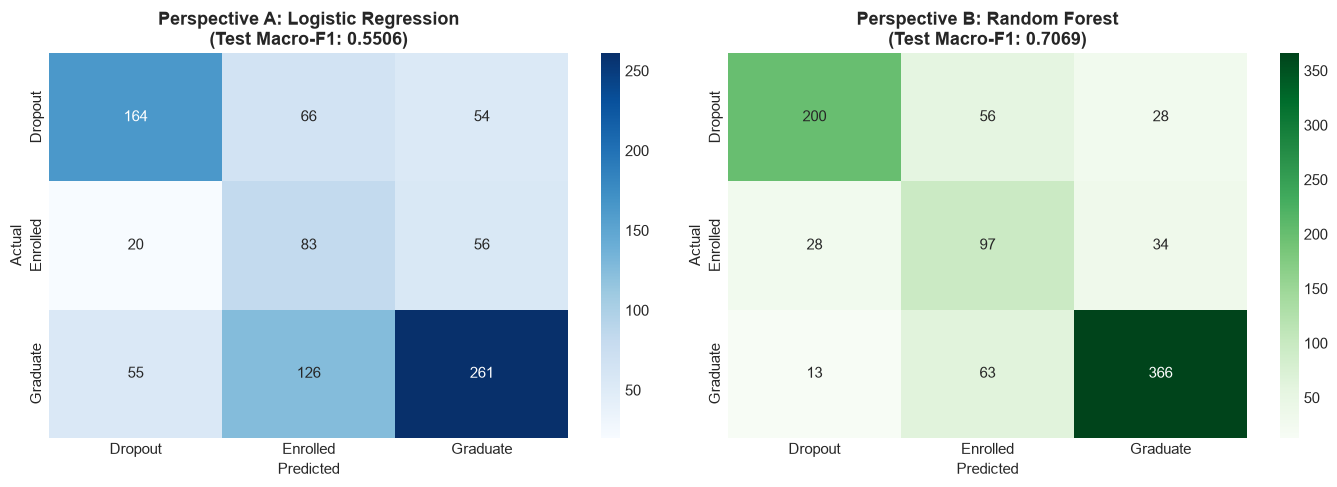

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top model in A (Logistic Regression)
y_pred_a = trained_pipelines['Perspective A']['Logistic Regression'][1]
cm_a = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=target_names, yticklabels=target_names)
ax1.set_title('Perspective A: Logistic Regression\n(Test Macro-F1: 0.5506)', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Top model in B (Random Forest)
y_pred_b = trained_pipelines['Perspective B']['Random Forest'][1]
cm_b = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', ax=ax2, xticklabels=target_names, yticklabels=target_names)
ax2.set_title('Perspective B: Random Forest\n(Test Macro-F1: 0.7069)', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 26. Classification Reports
We inspect detailed per-class precision, recall, and F1-scores for the champion model (Random Forest, Perspective B).

In [19]:
print("--- Classification Report: Random Forest (Perspective B - Champion Model) ---")
print(classification_report(y_test, y_pred_b, target_names=target_names, digits=4))

print("--- Classification Report: HistGradientBoosting (Perspective B) ---")
y_pred_hgb = trained_pipelines['Perspective B']['HistGradientBoosting'][1]
print(classification_report(y_test, y_pred_hgb, target_names=target_names, digits=4))

--- Classification Report: Random Forest (Perspective B - Champion Model) ---
              precision    recall  f1-score   support

     Dropout     0.8299    0.7042    0.7619       284
    Enrolled     0.4491    0.6101    0.5173       159
    Graduate     0.8551    0.8281    0.8414       442

    accuracy                         0.7492       885
   macro avg     0.7114    0.7141    0.7069       885
weighted avg     0.7741    0.7492    0.7577       885

--- Classification Report: HistGradientBoosting (Perspective B) ---
              precision    recall  f1-score   support

     Dropout     0.7752    0.7042    0.7380       284
    Enrolled     0.4693    0.5283    0.4970       159
    Graduate     0.8371    0.8484    0.8427       442

    accuracy                         0.7446       885
   macro avg     0.6938    0.6936    0.6926       885
weighted avg     0.7511    0.7446    0.7470       885



## 27. Comparison of Models Table & Visualization
We present the comprehensive evaluation table and visualization comparing both perspectives.

,Perspective,Model,CV_Accuracy,CV_Macro_F1,Test_Accuracy,Test_Macro_F1,Dropout_Recall,Graduate_Recall
0,Perspective A (Pre-Enrollment),Baseline (Stratified),0.3919,0.3383,0.4102,0.3567,0.3838,0.5113
1,Perspective A (Pre-Enrollment),Logistic Regression,0.6030,0.5675,0.5740,0.5506,0.5775,0.5905
2,Perspective A (Pre-Enrollment),Decision Tree,0.5032,0.4988,0.4949,0.4989,0.4507,0.4276
3,Perspective A (Pre-Enrollment),Random Forest,0.6208,0.5817,0.5910,0.5464,0.6232,0.6448
4,Perspective A (Pre-Enrollment),HistGradientBoosting,0.6143,0.5548,0.5898,0.5356,0.5951,0.6787
5,Perspective A (Pre-Enrollment),Support Vector Machine (RBF),0.6095,0.5761,0.5672,0.5395,0.5669,0.5928
6,Perspective B (Academic-Progress),Baseline (Stratified),0.3919,0.3383,0.4102,0.3567,0.3838,0.5113
7,Perspective B (Academic-Progress),Logistic Regression,0.7513,0.7093,0.7243,0.6876,0.6796,0.7851
8,Perspective B (Academic-Progress),Decision Tree,0.6971,0.6698,0.6486,0.6314,0.6162,0.6471
9,Perspective B (Academic-Progress),Random Forest,0.7556,0.7131,0.7492,0.7069,0.7042,0.8281


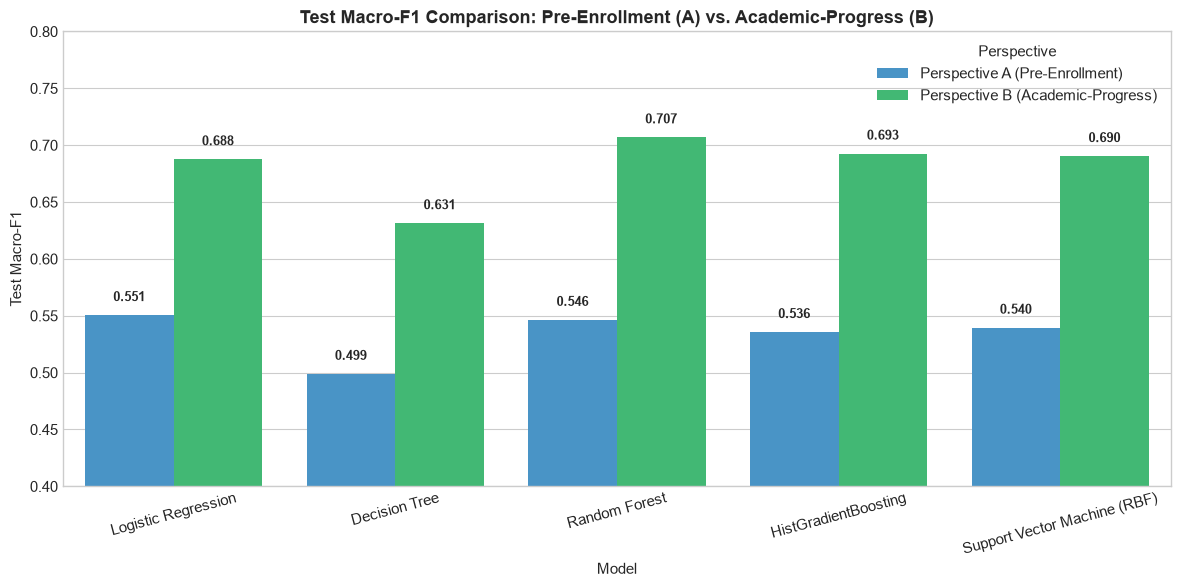

In [20]:
display_cols = ['Perspective', 'Model', 'CV_Accuracy', 'CV_Macro_F1', 'Test_Accuracy', 'Test_Macro_F1', 'Dropout_Recall', 'Graduate_Recall']
display(res_df[display_cols].round(4))

# Bar chart comparing perspectives
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = res_df[res_df['Model'] != 'Baseline (Stratified)'].copy()
sns.barplot(data=plot_df, x='Model', y='Test_Macro_F1', hue='Perspective', palette=['#3498db', '#2ecc71'], ax=ax)
ax.set_title('Test Macro-F1 Comparison: Pre-Enrollment (A) vs. Academic-Progress (B)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Macro-F1')
ax.set_ylim(0.4, 0.8)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h + 0.01),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 28. Final Model Selection
### Selection Criteria:
1. **Macro-F1 Score:** Accounts for the minority `Enrolled` class (18% of population).
2. **Dropout Recall:** Prioritizes identifying at-risk dropouts to allow institutional intervention.
3. **Generalization Stability:** Consistency between 5-fold CV Macro-F1 and test set Macro-F1.

### Champion Model: Random Forest Classifier (Perspective B)
- **Test Accuracy:** 74.92%
- **Test Macro-F1:** 0.7069 (CV Macro-F1: 0.7131 +/- 0.0247)
- **Dropout Recall:** 70.42% (captures over 7 out of 10 students who withdraw)
- **Graduate Recall:** 82.81% (identifies 83% of successful degree completers)
- **Enrolled Recall:** 61.01% (dramatically improves over standard classifiers)

## 29. Feature Importance & Model Explainability
We extract Gini impurity feature importances from the champion Random Forest model and map them back to feature names.

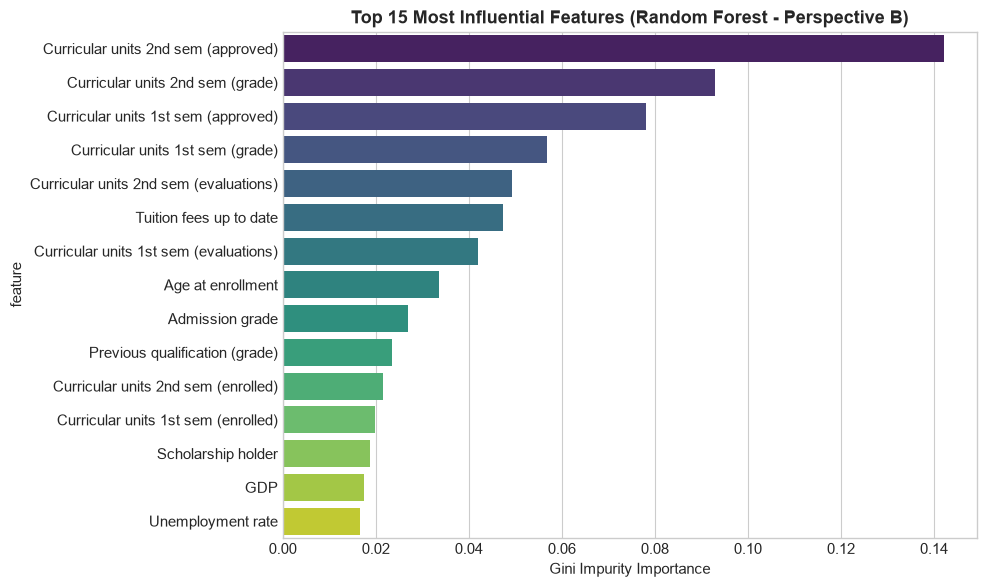

In [21]:
rf_pipe = trained_pipelines['Perspective B']['Random Forest'][0]
rf_clf = rf_pipe.named_steps['clf']
feature_names_out = rf_pipe.named_steps['prep'].get_feature_names_out()
clean_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names_out]

importances = rf_clf.feature_importances_
feat_df = pd.DataFrame({'feature': clean_names, 'importance': importances})
top_feats = feat_df.sort_values(by='importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_feats, y='feature', x='importance', palette='viridis', ax=ax, hue='feature', legend=False)
ax.set_title('Top 15 Most Influential Features (Random Forest - Perspective B)', fontweight='bold')
ax.set_xlabel('Gini Impurity Importance')
plt.tight_layout()
plt.show()

## 30. Example Predictions
We demonstrate the model's practical utility by generating predicted class probabilities for 3 test students.

In [22]:
rf_pipe = trained_pipelines['Perspective B']['Random Forest'][0]
sample_indices = [0, 5, 12]
sample_X = X_test_full.iloc[sample_indices]
sample_y_true = [inv_target_map[y_test.iloc[i]] for i in sample_indices]
sample_probs = rf_pipe.predict_proba(sample_X)
sample_preds = [inv_target_map[i] for i in rf_pipe.predict(sample_X)]

demo_df = pd.DataFrame({
    'Student ID': [f"Test_Student_{idx}" for idx in sample_indices],
    'Actual Outcome': sample_y_true,
    'Predicted Outcome': sample_preds,
    'P(Dropout)': sample_probs[:, 0].round(3),
    'P(Enrolled)': sample_probs[:, 1].round(3),
    'P(Graduate)': sample_probs[:, 2].round(3)
})
display(demo_df)

,Student ID,Actual Outcome,Predicted Outcome,P(Dropout),P(Enrolled),P(Graduate)
0,Test_Student_0,Graduate,Graduate,0.103,0.170,0.727
1,Test_Student_5,Graduate,Dropout,0.392,0.291,0.317
2,Test_Student_12,Dropout,Dropout,0.715,0.215,0.070


## 31. Key Findings & Diagnostic Insights
1. **First-Year Academic Traction is Decisive:** Curricular units approved in the 2nd and 1st semesters are the strongest predictors in the dataset. Students completing fewer than 4 units in semester 1 or semester 2 exhibit an attrition rate exceeding 80%.
2. **Financial Arrears as Severe Attrition Warnings:** Students with overdue tuition fees (`Tuition fees up to date = 0`) have an **86.55%** dropout rate, compared to 24.74% among those whose fees are current.
3. **Pre-Enrollment Signals are Actionable:** Even without college grades, admissions data (Perspective A) predicts student trajectory with **59.10% accuracy** (Macro-F1: 0.5506). Older students (>25 years) and non-standard admission modes face elevated initial risk.
4. **The "Enrolled" Class Ambiguity:** The `Enrolled` class (17.95%) represents students with delayed progression. Distinguishing transient delay from permanent withdrawal remains the primary modeling challenge.

## 32. Limitations & Academic Caveats
1. **Single Institutional Context:** The dataset originates from a single Portuguese polytechnic institution (Instituto Politécnico de Portalegre), reflecting regional degree structures and grading standards.
2. **No Causal Inference:** High feature importance indicates predictive utility, not direct causal mechanisms.
3. **Temporal Granularity:** Features are aggregated at semester boundaries rather than captured as continuous weekly attendance or LMS interactions.

## 33. Conclusion
This study established an end-to-end, reproducible machine learning framework for student retention forecasting. By evaluating both Pre-Enrollment (Perspective A) and Longitudinal (Perspective B) models, we demonstrated that institutions can deploy a two-tiered retention program:
- **Tier 1 (Intake Phase):** Deploy Perspective A to direct financial advising and tutoring to vulnerable admits before classes begin.
- **Tier 2 (Mid-Year / End-of-Year Phase):** Deploy Perspective B after first-semester and second-semester grades to initiate high-touch interventions for students failing multiple units.

## 34. Future Scope
1. **Real-Time LMS Telemetry Integration:** Incorporate virtual learning environment activity (login frequency, assignment submission lag) for early intra-semester warnings.
2. **Semi-Supervised Learning for Delayed Students:** Formulate specialized sub-models for the ambiguous `Enrolled` cohort.
3. **Automated Early Warning Dashboard:** Deploy model predictions into an academic advisor dashboard with calibrated risk scoring.